In [1]:
import torch

In [2]:
from sampling import sample_domain

In [3]:
def residual_based_adaptive_sampling(X, residual_fn, n_new=1000, picking_criterion="multinomial"):
    """
    sampling_strategy: "lhs" or "uniform"
    picking_criterion: "multinomial" or "top_k"
    Returns (X_selected,) for pde/ic, or (X_selected, normals_selected) for bc.
    """
    k = 1
    c = 0.0

    # rbas logic:
    res = residual_fn(X)
    abs_res = res.abs().squeeze()

    if picking_criterion == "top_k":
        _, idx = torch.topk(abs_res, n_new)
    elif picking_criterion == "multinomial":
        probs = abs_res**k / (abs_res**k).sum() + c
        probs /= probs.sum()
        idx = torch.multinomial(probs, n_new, replacement=False)
    else:
        raise NameError("Provide a correct picking crierion.")

    return X[idx].detach(), None

In [4]:
X = sample_domain(100_000, 2, "lhs")
print(X.shape)
X.min(), X.max()

torch.Size([100000, 2])


(tensor(1.5570e-06), tensor(1.0000))

In [5]:
res_f = lambda x: torch.exp(-30.0*((x-0.5)**2).sum(dim=1))
res_f(X).shape

torch.Size([100000])

In [6]:
X_rbas = residual_based_adaptive_sampling(X, res_f, n_new=1_000)[0]
X_rbas.shape

torch.Size([1000, 2])

In [7]:
import matplotlib.pyplot as plt

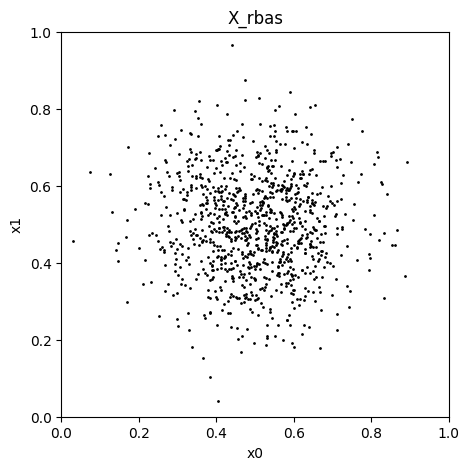

In [8]:
plt.figure(figsize=(5, 5))
plt.scatter(X_rbas[:, 0], X_rbas[:, 1], c="black", s=1)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("X_rbas")
plt.show()

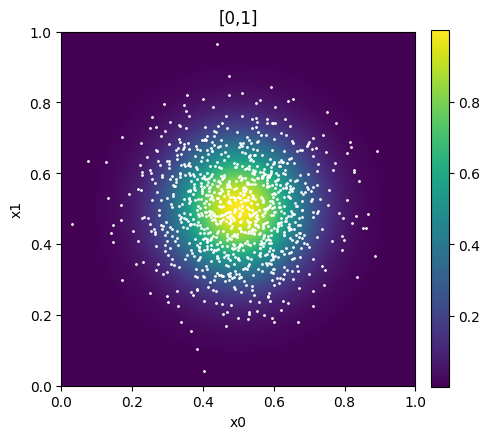

In [9]:
n = 200
xs = torch.linspace(0, 1, n)
ys = torch.linspace(0, 1, n)
gx, gy = torch.meshgrid(xs, ys, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)
Z = res_f(grid).reshape(n, n)

fig, ax = plt.subplots(figsize=(5, 5))
pcm = ax.pcolormesh(gx, gy, Z, shading="auto")
fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
ax.scatter(X_rbas[:, 0], X_rbas[:, 1], c="white", s=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("[0,1]")
plt.show()

In [10]:
def rad_sampling(X, residual_fn, n_new, k=1.0, c=0.0):
    """RAD: p(x) ~ eps(x)^k / mean(eps(x)^k) + c."""
    eps = residual_fn(X).abs().squeeze()
    w = eps.pow(k)
    probs = w / w.mean() + c
    probs = probs / probs.sum()
    idx = torch.multinomial(probs, n_new, replacement=False)
    return X[idx].detach()

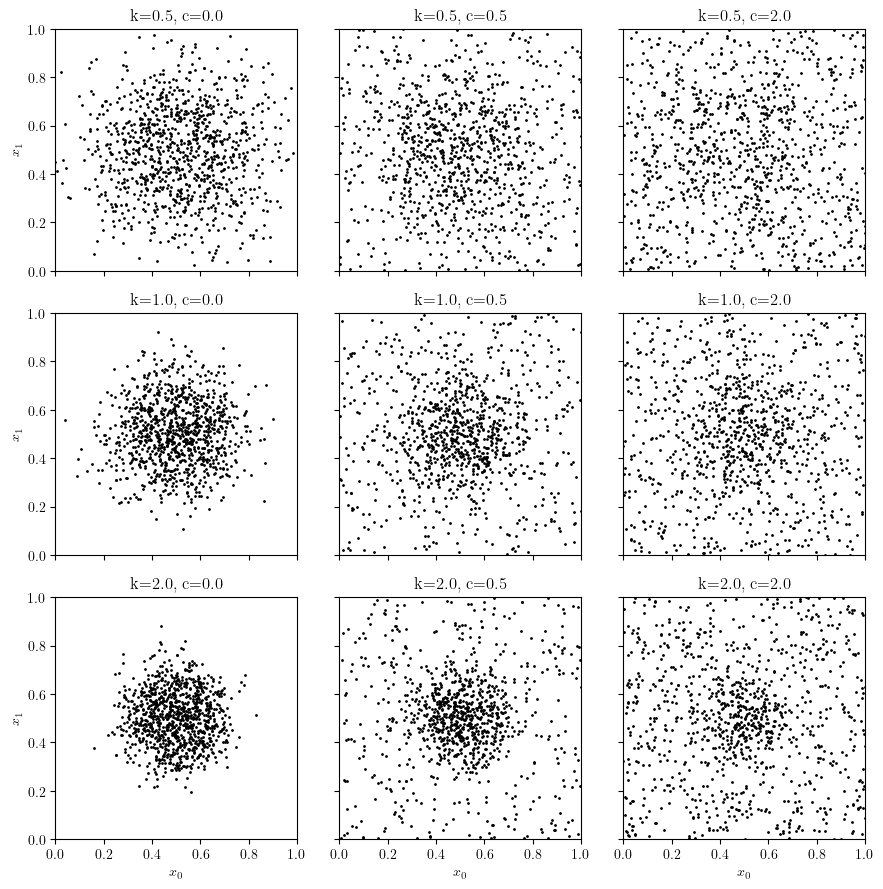

In [13]:
k_vals = [0.5, 1.0, 2.0]
c_vals = [0.0, 0.5, 2.0]

X_pool = sample_domain(10_000, 2, "lhs")
n_new = 1_000

import matplotlib as mpl
# Configure Matplotlib to use LaTeX for text rendering
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
fig, axes = plt.subplots(len(k_vals), len(c_vals),
                         figsize=(3 * len(c_vals), 3 * len(k_vals)),
                         sharex=True, sharey=True)

for i, k in enumerate(k_vals):
    for j, c in enumerate(c_vals):
        ax = axes[i, j]
        pts = rad_sampling(X_pool, res_f, n_new, k=k, c=c)
        ax.scatter(pts[:, 0], pts[:, 1], c="black", s=1)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.set_title(f"k={k}, c={c}")

for ax in axes[-1, :]:
    ax.set_xlabel(r"$x_0$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$x_1$")

fig.tight_layout()
plt.savefig("sampling_kc.png", dpi=200)
plt.show()